In [78]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
import pandas as pd                     
import numpy as np                      
import matplotlib.pyplot as plt         
import seaborn as sns                   
import scipy.stats as stats             
import regression
import matplotlib


In [80]:
%matplotlib inline


In [81]:
def add_column(df: pd.DataFrame) -> None:
    df["аик+переливание_крови"] = df["аик"] * (df["объем_гемотрансфузии"].apply(lambda x: 1 if x > 0 else 0))

In [82]:
def check_duplicates(df: pd.DataFrame) -> None:
    df.drop_duplicates(inplace=True)

In [83]:
def drop_nan(df: pd.DataFrame) -> None:
    df.dropna(inplace=True)

In [84]:
def fix_types(df: pd.DataFrame) -> None:
    df["развитие_опп"] = df["развитие_опп"].apply(lambda x: 0 if x == "нет" else 1)
    df["хбп"] = df["хбп"].apply(lambda x: 0 if x == "Пациенты без ХБП" else 1 if x == "Стадия C1-C2" else 2)
    for column in df.select_dtypes(include=["object"]).columns:
        df[column] = df[column].apply(lambda x: float(x.replace(",", ".").replace("o", "0")) if type(x) != float else x)

In [85]:
def drop_outliers(df: pd.DataFrame, a=3) -> tuple:
    columns = df.columns
    outliers_all = np.array([False for i in range(len(df))])
    for column in columns:
        if len(df[column].unique()) > len(df) * 0.05:
            std = df[column].std()
            median = df[column].median()
            outliers = abs(df[[column]] - median) > a * std
            outliers_all = np.bitwise_or(outliers.to_numpy().flatten(), outliers_all)
    df_unchanged = df.copy()
    df = df[~ outliers_all].dropna()
    return df, df_unchanged, outliers_all

In [86]:
def preprocess(df_name: str) -> pd.DataFrame:
    df = pd.read_csv(df_name)
    df.columns = [x.lower().replace(" ", "_").replace(",", "") for x in df.columns]
    df.columns = [x[:-1] if x[-1] == "_" else x for x in df.columns]
    fix_types(df)
    drop_nan(df)
    check_duplicates(df)
    df, unchanged_df, outliers = drop_outliers(df)
    add_column(df)
    return df.reset_index()

In [87]:
df = preprocess("medics_1.csv")
df

,index,развитие_опп,хбп,возраст,пол,гб,сахарный_диабет,стенокардия,инфаркт_миокарда,мерцательная_аритмия,...,аик,количество_шунтов,длительность_операции,длительность_аик,время_пережатия_аорты,объем_кровопотерии,объем_гемотрансфузии,объем_инфузий,диурез,аик+переливание_крови
0,3,0,1,62,1,1,0,1,1,1,...,1,3,210,71,43,500,1283,1700,1700,1
1,4,1,1,55,1,1,1,1,1,0,...,1,3,265,116,74,500,1560,1800,1300,1
2,5,0,0,60,1,1,0,1,1,0,...,1,3,240,74,62,200,1350,2100,1800,1
3,8,0,1,60,1,1,0,1,0,0,...,1,3,299,122,75,500,600,1050,4000,1
4,9,1,1,58,1,1,1,1,0,1,...,1,2,185,64,55,500,540,1200,700,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,190,1,0,77,1,1,0,1,0,0,...,1,4,260,75,56,500,1849,1700,1600,1
87,191,0,1,66,1,1,0,1,0,1,...,1,2,250,62,45,500,1460,2400,1600,1
88,194,0,0,47,1,1,0,1,0,0,...,1,3,290,98,55,250,1094,1200,2000,1
89,196,1,1,68,1,1,0,1,0,1,...,0,2,220,0,0,150,0,1400,2000,0


In [88]:
def is_categorical(df: pd.DataFrame, column: str) -> bool:
    return len(df[column].unique()) < len(df) * 0.05


In [89]:
def check_correlations(df: pd.DataFrame) -> list:
    columns = ["возраст", "сахарный_диабет", "гб", "хбп", "сад", "дад", "чсс", "рн", "фракция_изгнания", "холестерин",
               "креатинин_крови", "мочевина", "скф_расч.", "калий", "имт", "толщина_паренхимы_почек"]
    res = []
    for x in columns:
        if is_categorical(df, x):
            temp = stats.chi2_contingency(pd.crosstab(df[x], df["развитие_опп"]))
            res.append([x, "развитие_опп", round(temp[1], 4), "Хи-квадрат"])
        else:
            if stats.shapiro(df[x])[1] > 0.05:
                temp = stats.ttest_ind(df["развитие_опп"], df[x])
                res.append([x, "развитие_опп", round(temp[1], 4), "T-критерий Стьюента"])
            else:
                temp = stats.mannwhitneyu(df["развитие_опп"], df[x])
                res.append([x, "развитие_опп",round(temp[1], 4), "U-критерий Манна-Уитни"])
    # print(*res, sep="\n")
    
    return pd.DataFrame(np.array(res), columns=["Фактор", "Развитие ОПП", "p-уровень", "Метод"])

In [90]:
def get_diagnosis(m: int) -> str:
    if m > 100:
        return "Пациенты без ХБП"
    if m > 60:
        return "Стадия C1-C2"
    return "Стадия С3"


In [91]:
def check_diagnosis(df: pd.DataFrame) -> list:  # ?
    num_to_words = {0: "Пациенты без ХБП", 1: "Стадия C1-C2", 2: "Стадия С3"}
    wrong_diagnosis = []
    for idx, row in df.iterrows():
        if row["скф_расч."] > 100:
            if row["хбп"] != 0:
                print(
                    f"У пациента {idx} диагноз {num_to_words[row['хбп']]}, но должен быть {get_diagnosis(row['скф_расч.'])}")
                wrong_diagnosis.append(idx)
        elif row["скф_расч."] > 60:
            if row["хбп"] != 1:
                print(
                    f"У пациента {idx} диагноз {num_to_words[row['хбп']]}, но должен быть {get_diagnosis(row['скф_расч.'])}")
                wrong_diagnosis.append(idx)
        elif row["скф_расч."] != 2:
            print(
                f"У пациента {idx} диагноз {num_to_words[row['хбп']]}, но должен быть {get_diagnosis(row['скф_расч.'])}")
            wrong_diagnosis.append(idx)
    return wrong_diagnosis

In [92]:
def poch_paren(df: pd.DataFrame) -> None:
    poch_paren = df[df["хбп"] == 0]
    print(stats.pearsonr(poch_paren["толщина_паренхимы_почек"], poch_paren["возраст"]))
    sns.scatterplot(data=poch_paren, x="толщина_паренхимы_почек", y="возраст")
    plt.show()

In [93]:
def imt_hol(df: pd.DataFrame) -> None:
    # !!! норма - 18,5-25 избыточный - 25-30, больше - ожирение
    # норма 3,6-7,8 ммоль и моль!!!
    df["ктг_имт"] = df["имт"].apply(lambda x: 1 if x > 25 else 0)
    df["ктг_холестерин"] = df["холестерин"].apply(lambda x: 1 if x > 7.8 else 0)
    imt_hol = pd.crosstab(df['ктг_имт'], df['ктг_холестерин'])
    print(imt_hol)
    print(stats.chi2_contingency(pd.crosstab(df['ктг_имт'], df['ктг_холестерин'])))
    sns.heatmap(imt_hol, cmap="YlGnBu", annot=True, cbar=False);
    plt.show()

In [94]:
def dependence_time_fact(df: pd.DataFrame) -> None:
    print(stats.pointbiserialr(df["инфаркт_миокарда"], df["длительность_операции"]))
    infarct_0 = df[df["инфаркт_миокарда"] == 0]
    infarct_1 = df[df["инфаркт_миокарда"] == 1]
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    plot = sns.boxplot(ax=axes[0], data=infarct_0, y="длительность_операции")
    plot2 = sns.boxplot(ax=axes[1], data=infarct_1, y="длительность_операции")
    plt.show()

In [95]:
def count_disease(df: pd.DataFrame, imt: str) -> list:
    lst = ["гб", "стенокардия", "инфаркт_миокарда", "желудочковая_экстрасистолия",
           "мерцательная_аритмия", "хсн", "нк"]
    answer = []
    for i in range(len(lst)):
        answer.append(df.loc[(df['имт_ном'] == imt) & (df[lst[i]] == 1), 'развитие_опп'].sum())
    return answer

In [96]:
def draw_chart(labels, sizes, name, fig, ax, row, column):
        colors = ['#506D2F', '#2a2922', '#f3ebdd', '#7d5642', "#626D71", "#cdcdc0", "#DDBC95"]
        # Plot

        wedges, texts = ax[row][column].pie(sizes, startangle=-40, colors=colors)

        # Inner circle
        centre_circle = plt.Circle((0, 0), 0.70, fc='white')
        fig = plt.gcf()
        fig.gca().add_artist(centre_circle)

        # Add labels
        ax[row][column].legend(wedges, labels,
                title="болезни",
                loc="center left",
                bbox_to_anchor=(1, 0, 0.5, 1))

        plt.setp(texts, size=12, weight="bold")
        ax[row][column].pie(sizes, labels=labels, colors=colors,
                autopct='%1.1f%%')
        ax[row][column].set_title(name)


In [97]:
def imt(df):

    # Подпункт 2
    df["имт_ном"] = df["имт"].apply(lambda x: "выраженный_дефицит_массы_тела" if x < 16
    else "недостаточная_масса_тела" if 16 <= x < 18.5
    else "норма" if 18.5 <= x < 25
    else "избыточная_масса_тела" if 25 <= x < 30
    else "ожирение_1_степени" if 30 <= x < 35
    else "ожирение_2_степени" if 35 <= x < 40
    else "ожирение_3_степени")
    # Показатели, которых хоть как-то связаны с сердцем:
    s = '''
    1. ГБ, сахарный диабет
    2. Стенокардия
    3. Инфаркт миокарда, Желудочковая экстрасистолия, Мерцательная аритмия, ХСН, НК
    Разброс: [20, 42]
    Сердце -- почки
    '''
    labels = ["ГБ", "Стенокардия", "Инфаркт миокарда", "Желудочковая экстрасистолия", "Мерцательная аритмия",
              "ХСН", "НК"]
    sizes_norma = count_disease(df, "норма")
    sizes_overweight = count_disease(df, "избыточная_масса_тела")
    sizes_one = count_disease(df, "ожирение_1_степени")
    sizes_two = count_disease(df, "ожирение_2_степени")
    # sizes_three = count_disease(df, "ожирение_3_степени")
    fig, ax = plt.subplots(2, 2, figsize=(36, 18))
    draw_chart(labels, sizes_norma, "норма", fig, ax, 0, 0)
    draw_chart(labels, sizes_overweight, "избыточная_масса_тела", fig, ax, 0, 1)
    draw_chart(labels, sizes_one, "ожирение_1_степени", fig, ax, 1, 0)
    draw_chart(labels, sizes_two, "ожирение_2_степени", fig, ax, 1, 1)
    # draw_chart(labels, sizes_three, "ожирение_3_степени")
    plt.show()

In [98]:
def chronic_diseases(df: pd.DataFrame) -> None:
    # Подпункт 1
    diabetes_mellitus_true = round(((df.loc[df['развитие_опп'] == 1, 'сахарный_диабет']
                                     .sum()) / (sum(df["развитие_опп"]))) * 100, 4)
    diabetes_mellitus_false = round(((df.loc[df['развитие_опп'] == 0, 'сахарный_диабет']
                                      .sum()) / (len(df['развитие_опп']) - sum(df["развитие_опп"]))) * 100, 4)

    hypertension_true = round(((df.loc[df['развитие_опп'] == 1, 'гб']
                                .sum()) / (sum(df["развитие_опп"]))) * 100, 4)
    hypertension_false = round(((df.loc[df['развитие_опп'] == 0, 'гб']
                                 .sum()) / (len(df['развитие_опп']) - sum(df["развитие_опп"]))) * 100, 4)

    df["хбп_бин"] = df["хбп"].apply(lambda x: 1 if x == 1 or x == 2 else 0)
    chronic_kidney_disease_true = round(((df.loc[df['хбп_бин'] == 1, 'развитие_опп']
                                          .sum()) / (sum(df["развитие_опп"]))) * 100, 4)
    chronic_kidney_disease_false = round(((df.loc[df['развитие_опп'] == 0, 'хбп_бин']
                                           .sum()) / (len(df['развитие_опп']) - sum(df["развитие_опп"]))) * 100, 4)

    print(str(diabetes_mellitus_true) + "%", str(diabetes_mellitus_false) + "%")
    print(str(hypertension_true) + "%", str(hypertension_false) + "%")
    print(str(chronic_kidney_disease_true) + "%", str(chronic_kidney_disease_false) + "%")
    # pd.set_option('display.max_rows', None)
    # print(df["хбп_бин"].to_string(index=False))
    # print(len(df["хбп"]))


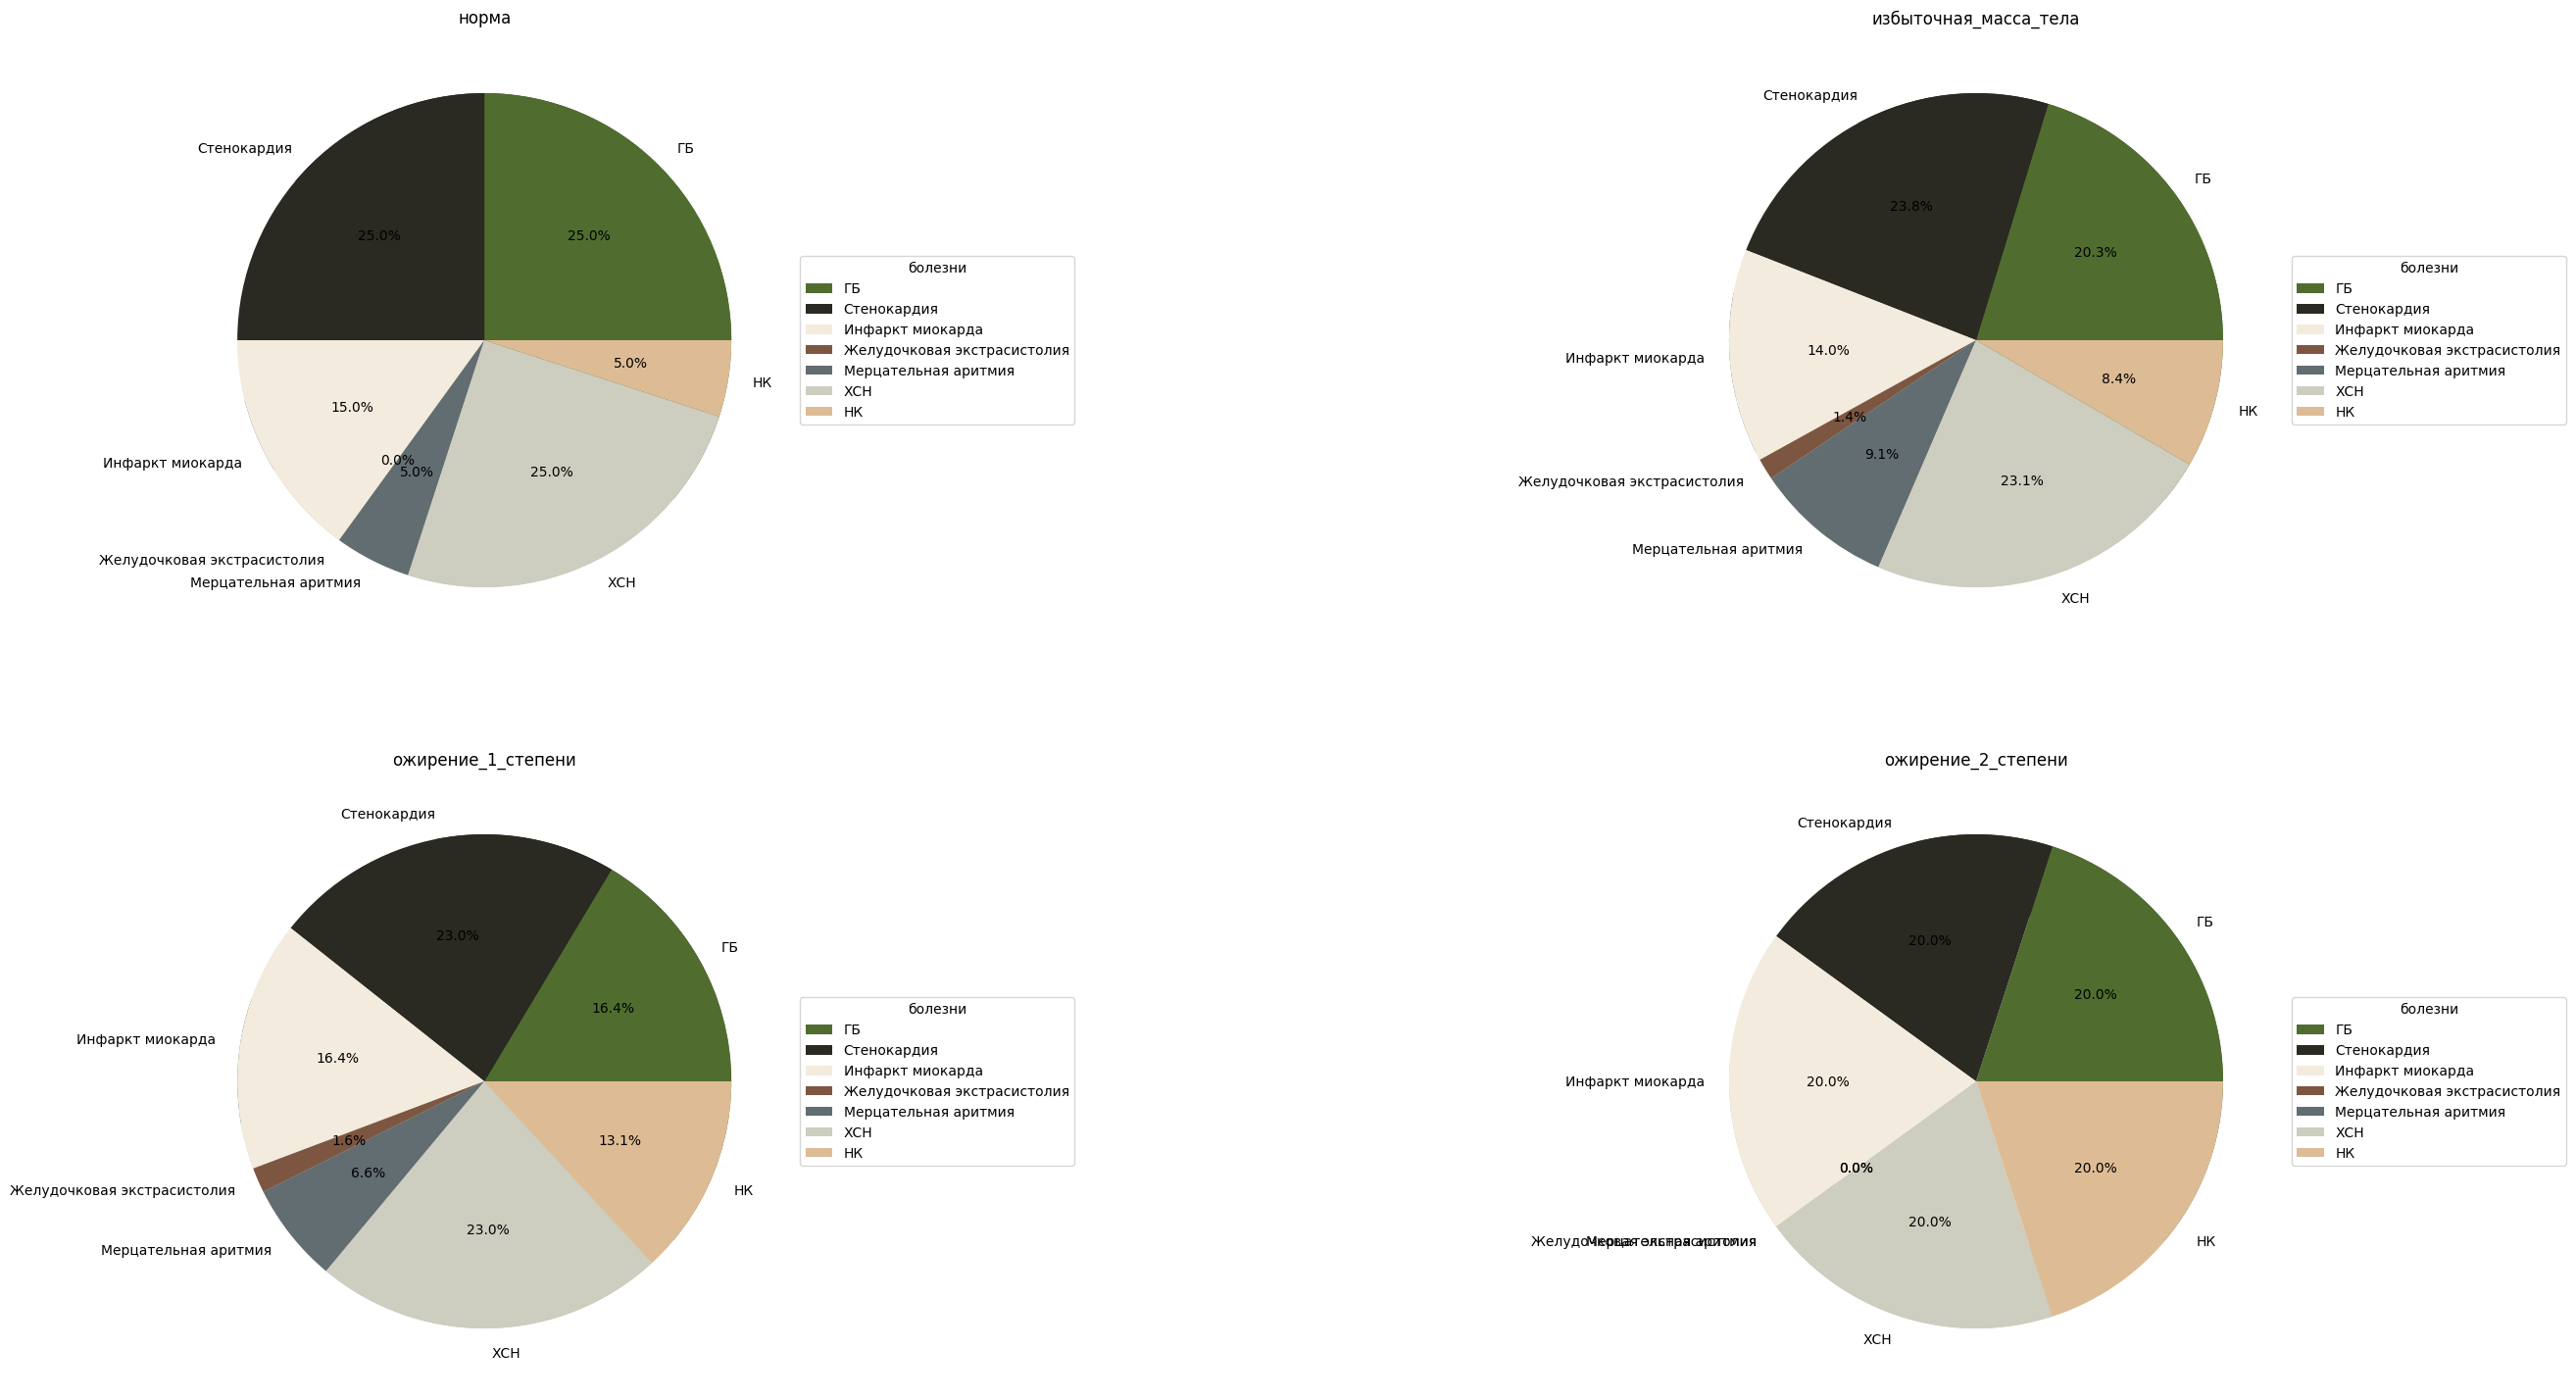

In [99]:
imt(df)

In [100]:
wrong_diagnsis = check_diagnosis(df)

У пациента 2 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
У пациента 6 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
У пациента 8 диагноз Стадия С3, но должен быть Стадия С3
У пациента 11 диагноз Стадия C1-C2, но должен быть Пациенты без ХБП
У пациента 12 диагноз Стадия C1-C2, но должен быть Пациенты без ХБП
У пациента 13 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
У пациента 15 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
У пациента 16 диагноз Стадия C1-C2, но должен быть Пациенты без ХБП
У пациента 20 диагноз Пациенты без ХБП, но должен быть Стадия С3
У пациента 21 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
У пациента 23 диагноз Стадия С3, но должен быть Стадия С3
У пациента 24 диагноз Пациенты без ХБП, но должен быть Стадия С3
У пациента 25 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
У пациента 28 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
У пациента 29 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
У пациент

SignificanceResult(statistic=0.05454838698202255, pvalue=0.6075682576361974)


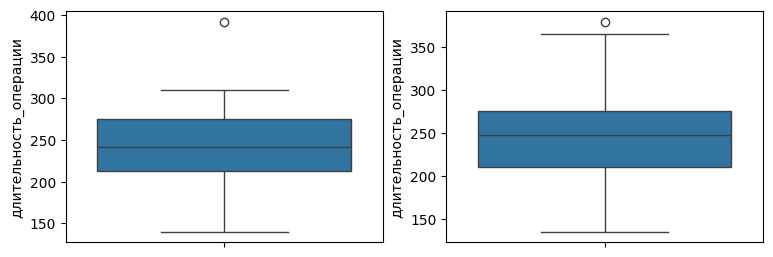

In [101]:
dependence_time_fact(df)


In [102]:
check_correlations(df)


,Фактор,Развитие ОПП,p-уровень,Метод
0,возраст,развитие_опп,0.0,T-критерий Стьюента
1,сахарный_диабет,развитие_опп,0.1129,Хи-квадрат
2,гб,развитие_опп,0.1545,Хи-квадрат
3,хбп,развитие_опп,0.584,Хи-квадрат
4,сад,развитие_опп,0.0,U-критерий Манна-Уитни
5,дад,развитие_опп,0.0,U-критерий Манна-Уитни
6,чсс,развитие_опп,0.0,U-критерий Манна-Уитни
7,рн,развитие_опп,0.0,U-критерий Манна-Уитни
8,фракция_изгнания,развитие_опп,0.0,U-критерий Манна-Уитни
9,холестерин,развитие_опп,0.0,T-критерий Стьюента


SignificanceResult(statistic=0.05454838698202255, pvalue=0.6075682576361974)


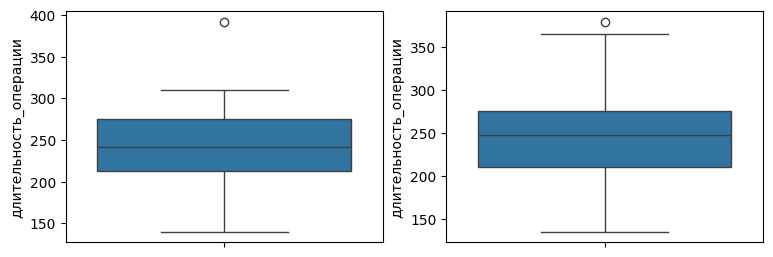

In [103]:
dependence_time_fact(df)


ктг_холестерин   0
ктг_имт           
0               18
1               73
Chi2ContingencyResult(statistic=0.0, pvalue=1.0, dof=0, expected_freq=array([[18.],
       [73.]]))


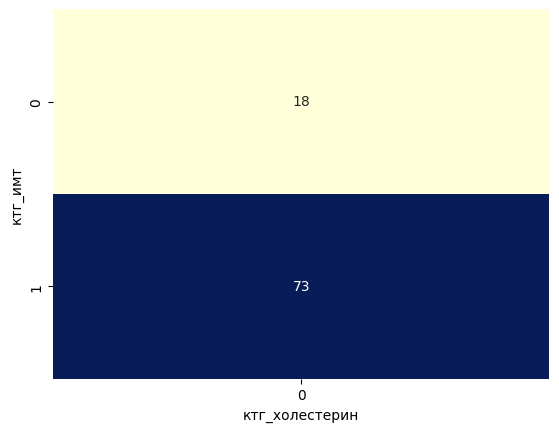

In [104]:
imt_hol(df)


PearsonRResult(statistic=-0.2286580163189256, pvalue=0.15584536629264173)


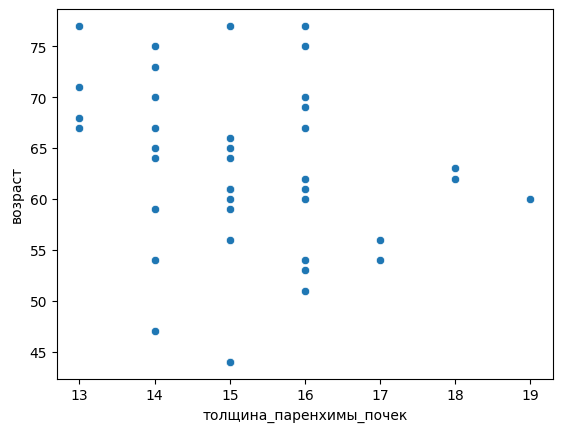

In [105]:
poch_paren(df)

In [106]:
check_correlations(df)

,Фактор,Развитие ОПП,p-уровень,Метод
0,возраст,развитие_опп,0.0,T-критерий Стьюента
1,сахарный_диабет,развитие_опп,0.1129,Хи-квадрат
2,гб,развитие_опп,0.1545,Хи-квадрат
3,хбп,развитие_опп,0.584,Хи-квадрат
4,сад,развитие_опп,0.0,U-критерий Манна-Уитни
5,дад,развитие_опп,0.0,U-критерий Манна-Уитни
6,чсс,развитие_опп,0.0,U-критерий Манна-Уитни
7,рн,развитие_опп,0.0,U-критерий Манна-Уитни
8,фракция_изгнания,развитие_опп,0.0,U-критерий Манна-Уитни
9,холестерин,развитие_опп,0.0,T-критерий Стьюента


In [107]:
test = check_correlations(df)

In [108]:
test = test.to_numpy()


In [109]:
test.T[2]

array(['0.0', '0.1129', '0.1545', '0.584', '0.0', '0.0', '0.0', '0.0',
       '0.0', '0.0', '0.0', '0.0', '0.0', '0.0', '0.0', '0.0'],
      dtype=object)

In [110]:
t = np.array([test.T[0], test.T[2] ])
t[1]

array(['0.0', '0.1129', '0.1545', '0.584', '0.0', '0.0', '0.0', '0.0',
       '0.0', '0.0', '0.0', '0.0', '0.0', '0.0', '0.0', '0.0'],
      dtype=object)

<Axes: >

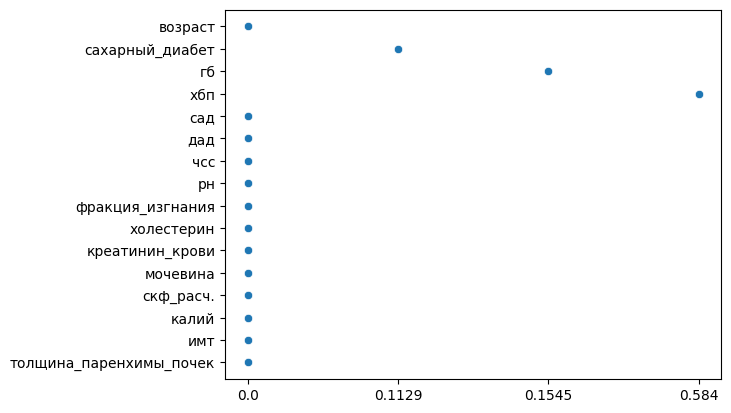

In [111]:
sns.scatterplot(x=t[1], y=t[0])